In [ ]:
# Uninstall existing versions to avoid conflicts
#!pip uninstall torch torchvision torchaudio -y

# Install the specific CUDA 12.6 enabled version for PyTorch 2.9.0
#!pip install torch==2.9.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
import torch
assert torch.cuda.is_available(), "GPU not enabled!"
print(f"GPU: {torch.cuda.get_device_name(0)}")


GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -U ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00


The image has dimensions 1024x768 and 3 channels
Index to Label Mapping: {0: 'fish', 1: 'jellyfish', 2: 'penguin', 3: 'puffin', 4: 'shark', 5: 'starfish', 6: 'stingray'}
Label to Index Mapping: {'fish': 0, 'jellyfish': 1, 'penguin': 2, 'puffin': 3, 'shark': 4, 'starfish': 5, 'stingray': 6}
Figure saved as 'output_image_grid.png'
Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/codes/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, forma

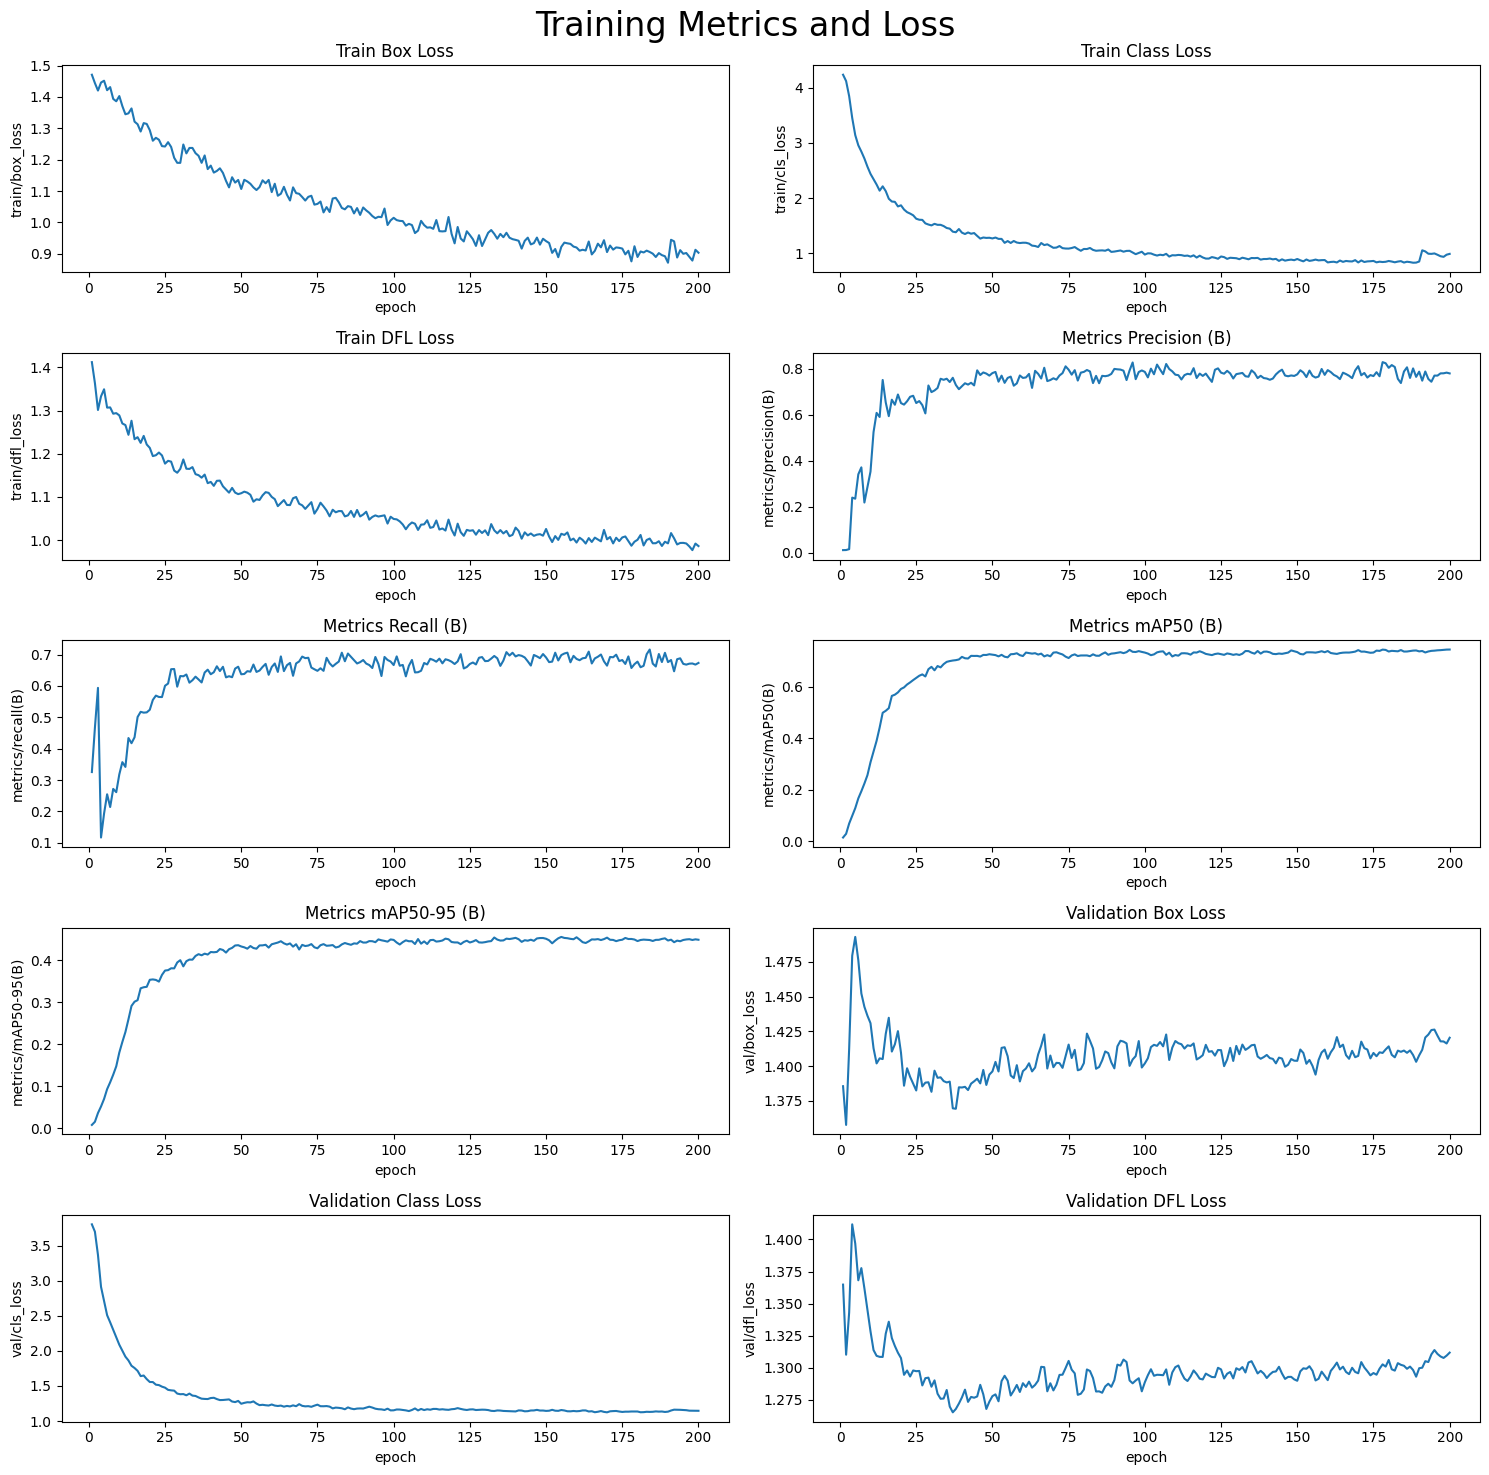

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.3±0.1 MB/s, size: 116.6 KB)
val: Scanning /content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/test/labels.cache... 63 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63 18.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 7.8s/it 31.3s
                   all         63        584      0.798      0.681      0.764      0.507
                  fish         30        249      0.806      0.719      0.805      0.509
             jellyfish         11        154      0.865      0.805      0.878      0.599
               penguin          7         82       0.76      0.734      0.779       0.35
                puffin          6         35      0

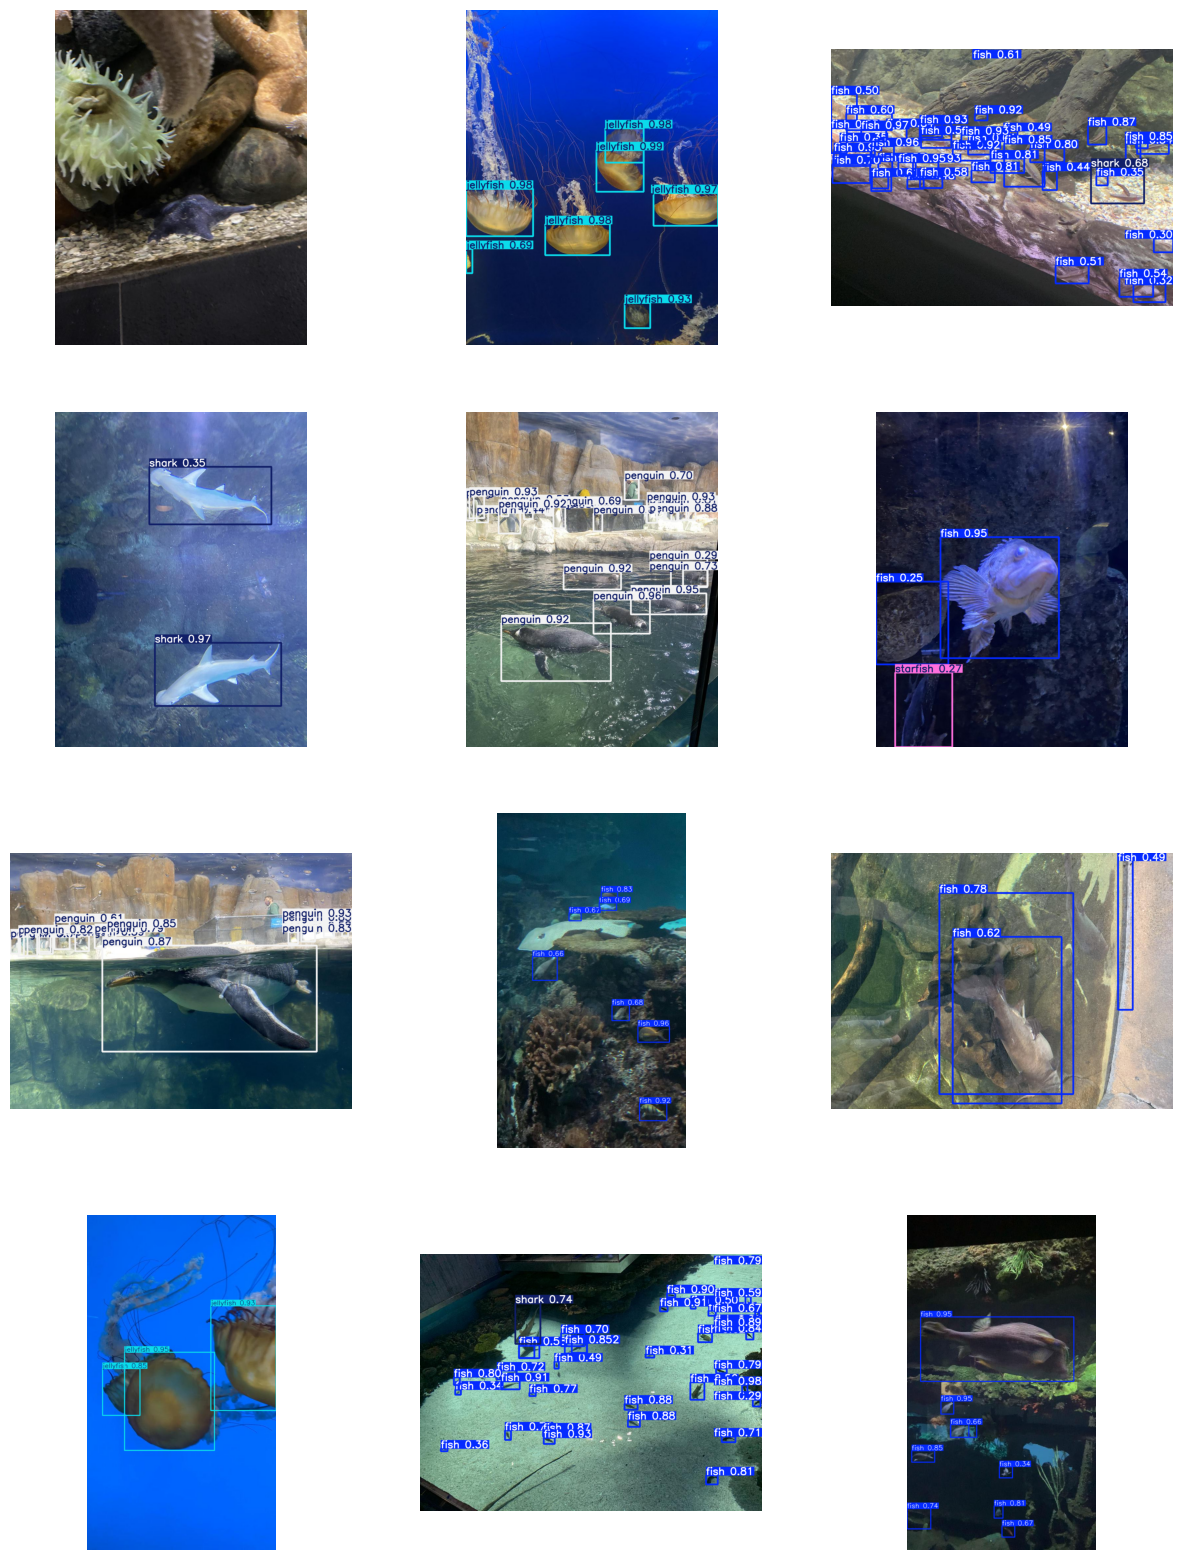

In [ ]:
import os
import random
import pandas as pd

import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import torch
from ultralytics import YOLO  # Corrected import statement


train_images = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/train/images'
train_labels = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/train/labels'

val_images = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/valid/images'
val_labels = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/valid/labels'

test_images = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/test/images'
test_labels = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/test/labels'


yaml_path = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/codes/data.yaml'


image_path = os.path.join(train_images, os.listdir(train_images)[100])
image = cv2.imread(image_path)

height, width, channels = image.shape
print('The image has dimensions {}x{} and {} channels'.format(height, width, channels))


classes = ['fish', 'jellyfish', 'penguin', 'puffin', 'shark', 'starfish', 'stingray']
Idx2Label = {idx: label for idx, label in enumerate(classes)}
Label2Index = {label: idx for idx, label in Idx2Label.items()}
print('Index to Label Mapping:', Idx2Label)
print('Label to Index Mapping:', Label2Index)


def visualize_image_with_annotation_bboxes(image_dir, label_dir):
    image_files = sorted(os.listdir(image_dir))
    sample_image_files = random.sample(image_files, 12)
    fig, axs = plt.subplots(4, 3, figsize=(15, 20))

    for i, image_file in enumerate(sample_image_files):
        row = i // 3
        col = i % 3

        image_path = os.path.join(image_dir, image_file)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label_path = os.path.join(label_dir, image_file[:-4] + '.txt')
        f = open(label_path, 'r')

        for label in f:
            class_id, x_center, y_center, width, height = map(float, label.split())
            h, w, _ = image.shape
            x_min = int((x_center - width / 2) * w)
            y_min = int((y_center - height / 2) * h)
            x_max = int((x_center + width / 2) * w)
            y_max = int((y_center + height / 2) * h)
            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
            cv2.putText(
                image,
                Idx2Label[int(class_id)],
                (x_min, y_min),
                cv2.FONT_HERSHEY_SIMPLEX,
                fontScale=1,
                color=(255, 255, 255),
                thickness=2
            )

        axs[row, col].imshow(image)
        axs[row, col].axis('off')

    plt.savefig('output_image_grid.png')
    plt.close()
    print("Figure saved as 'output_image_grid.png'")


visualize_image_with_annotation_bboxes(train_images, train_labels)


model = YOLO('yolov8n.pt')

results = model.train(
    data=yaml_path,
    epochs=200,
    imgsz=(height, width, channels),
    lr0=0.01,
    lrf=0.01,
    seed=42,
    batch=8,
    workers=4,
    device=0,
    name='underwater_detection'
)


print(f"mAP50: {results.box.map50:.4f}")

# Corrected path for the results CSV file
df = pd.read_csv(f'{results.save_dir}/results.csv')
df.columns = df.columns.str.strip()

fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))

sns.lineplot(x='epoch', y='train/box_loss', data=df, ax=axs[0, 0])
sns.lineplot(x='epoch', y='train/cls_loss', data=df, ax=axs[0, 1])
sns.lineplot(x='epoch', y='train/dfl_loss', data=df, ax=axs[1, 0])
sns.lineplot(x='epoch', y='metrics/precision(B)', data=df, ax=axs[1, 1])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=df, ax=axs[2, 0])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=df, ax=axs[2, 1])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=df, ax=axs[3, 0])
sns.lineplot(x='epoch', y='val/box_loss', data=df, ax=axs[3, 1])
sns.lineplot(x='epoch', y='val/cls_loss', data=df, ax=axs[4, 0])
sns.lineplot(x='epoch', y='val/dfl_loss', data=df, ax=axs[4, 1])

axs[0, 0].set(title='Train Box Loss')
axs[0, 1].set(title='Train Class Loss')
axs[1, 0].set(title='Train DFL Loss')
axs[1, 1].set(title='Metrics Precision (B)')
axs[2, 0].set(title='Metrics Recall (B)')
axs[2, 1].set(title='Metrics mAP50 (B)')
axs[3, 0].set(title='Metrics mAP50-95 (B)')
axs[3, 1].set(title='Validation Box Loss')
axs[4, 0].set(title='Validation Class Loss')
axs[4, 1].set(title='Validation DFL Loss')

plt.suptitle('Training Metrics and Loss', fontsize=24)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()

# Corrected path for loading the trained model
model = YOLO(f'{results.save_dir}/weights/best.pt')

metrics = model.val(conf=0.25, split='test')

def predict_detection(image_path):
    image = cv2.imread(image_path)
    detect_result = model(image)
    detect_image = detect_result[0].plot()
    detect_image = cv2.cvtColor(detect_image, cv2.COLOR_BGR2RGB)
    return detect_image


image_files = sorted(os.listdir(test_images))
sample_image_files = random.sample(image_files, 12)

fig, axs = plt.subplots(4, 3, figsize=(15, 20))

for i, image_file in enumerate(sample_image_files):
    row = i // 3
    col = i % 3

    image_path = os.path.join(test_images, image_file)
    detect_image = predict_detection(image_path)

    axs[row, col].imshow(detect_image)
    axs[row, col].axis('off')

plt.show()

In [ ]:
# =============================
# CONFUSION MATRIX EXPORT
# =============================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm = metrics.confusion_matrix.matrix

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt=".0f",
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

NameError: name 'metrics' is not defined

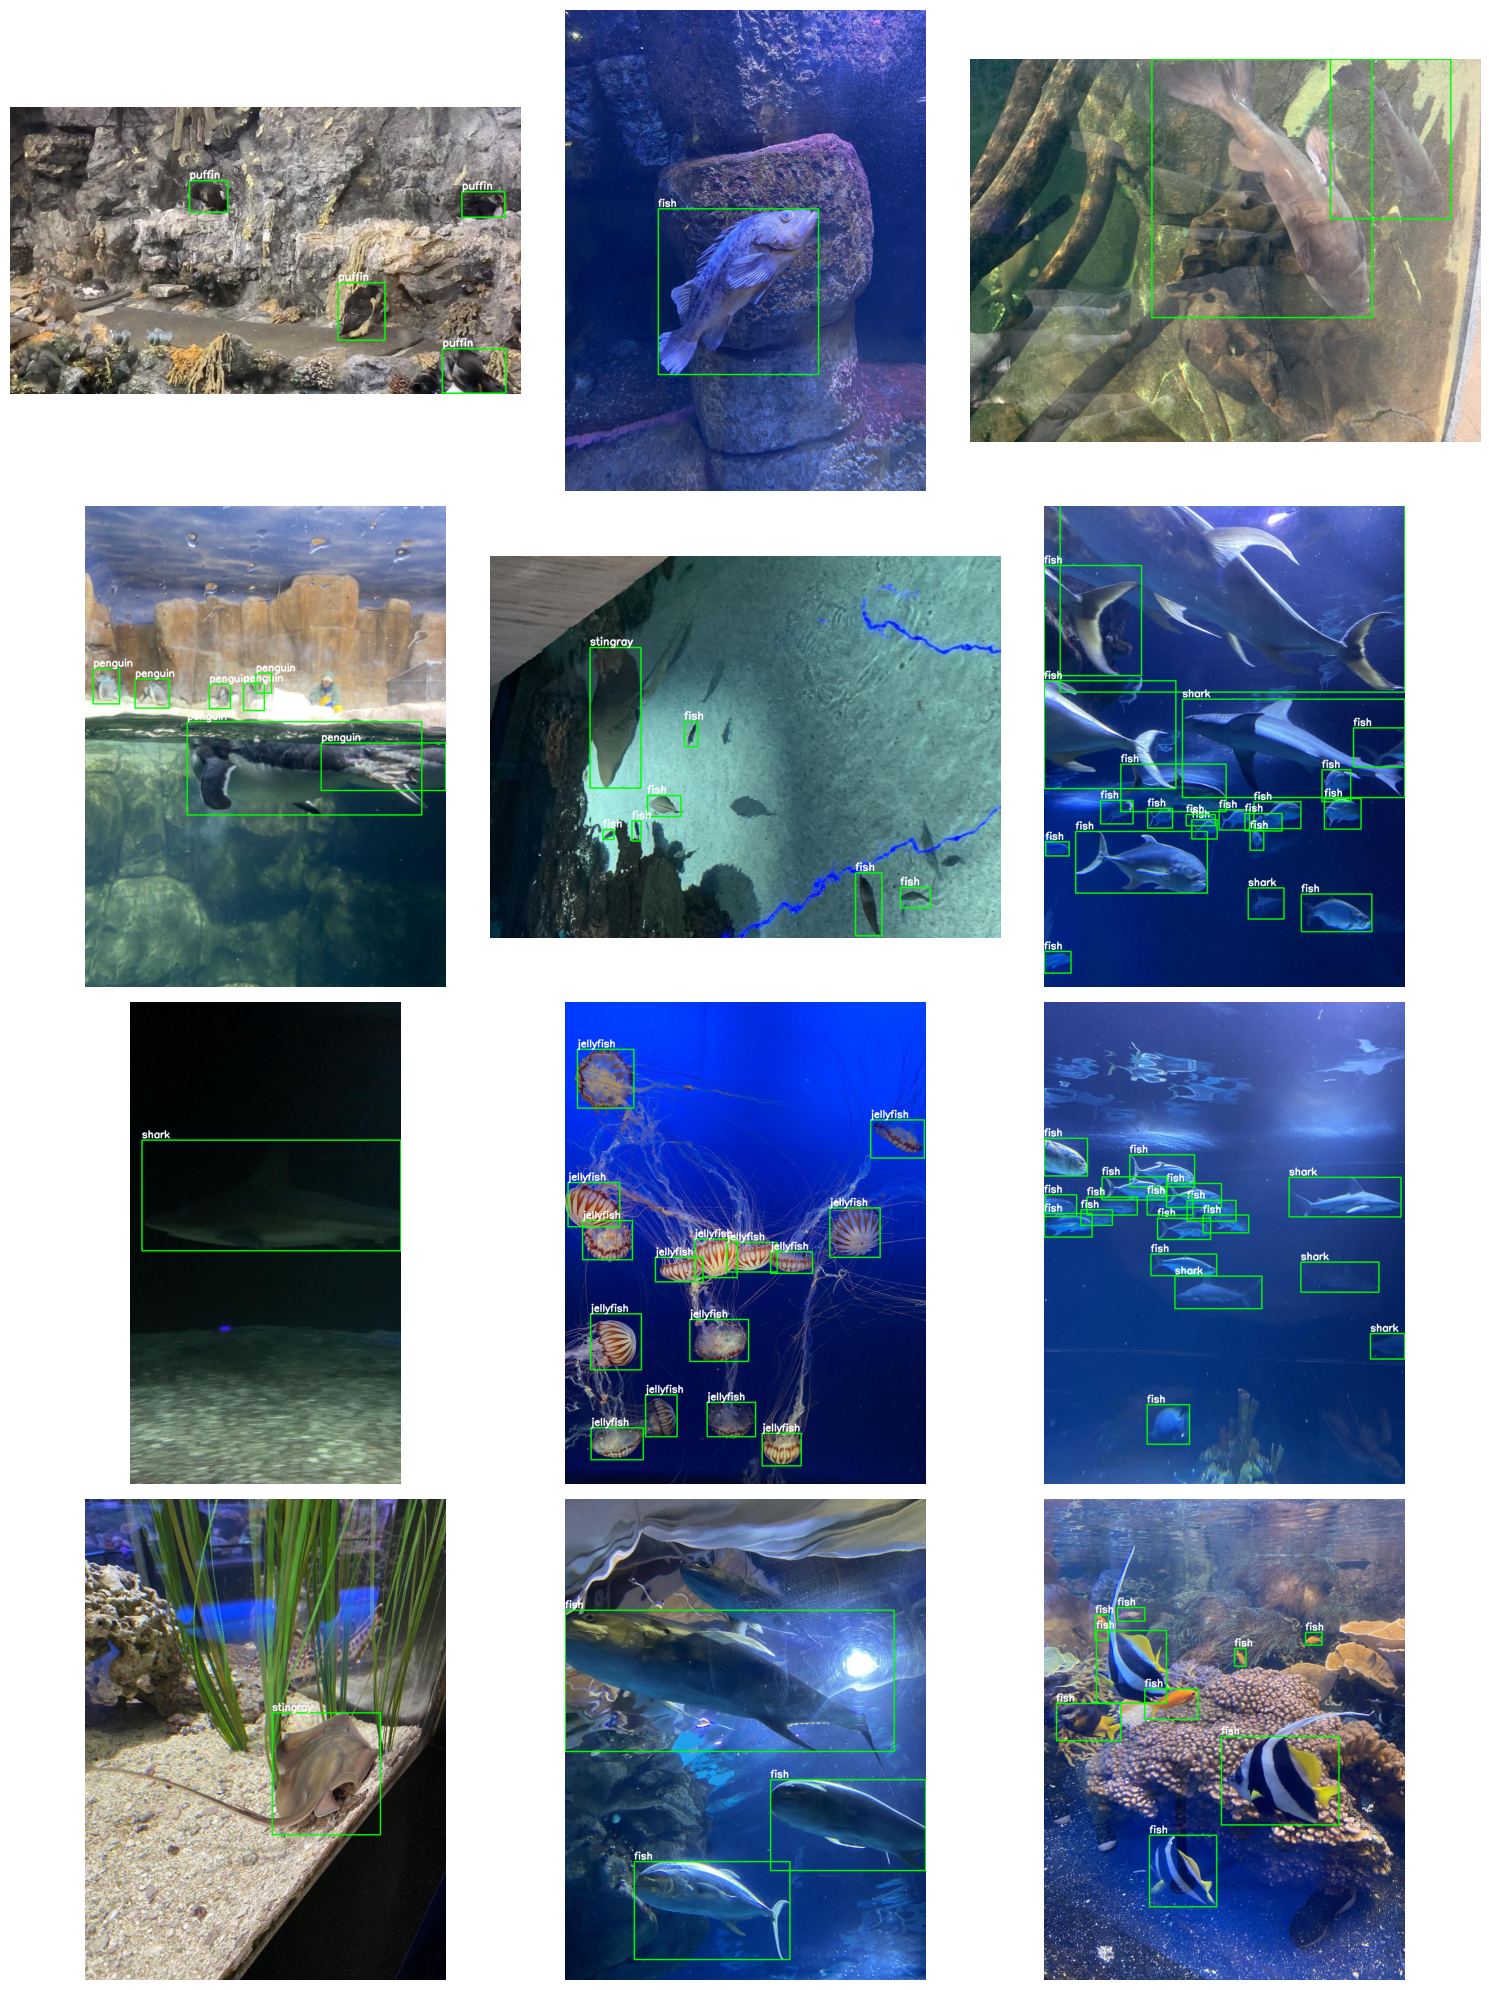

Loaded pretrained model: /content/drive/MyDrive/run/content/runs/detect/underwater_detection/weights/best.pt


SyntaxError: '[31m[1mhsv[0m' is not a valid YOLO argument. Similar arguments are i.e. ['hsv_v=0.4', 'hsv_s=0.7', 'hsv_h=0.015'].
'[31m[1mblur[0m' is not a valid YOLO argument. 

    Arguments received: ['yolo', '-f', '/root/.local/share/jupyter/runtime/kernel-9d2bddb9-d1d6-4e7b-aef4-8f2f65cda356.json']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of ['obb', 'segment', 'classify', 'detect', 'pose']
                MODE (required) is one of ['track', 'export', 'val', 'predict', 'train', 'benchmark']
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg or with 'yolo cfg'

    1. Train a detection model for 10 epochs with an initial learning_rate of 0.01
        yolo train data=coco8.yaml model=yolo26n.pt epochs=10 lr0=0.01

    2. Predict a YouTube video using a pretrai

In [ ]:
import os
import random
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import torch
from ultralytics import YOLO

# ---------------------------------------------------
# DATA PATHS (UNCHANGED)
# ---------------------------------------------------

train_images = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/train/images'
train_labels = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/train/labels'

val_images = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/valid/images'
val_labels = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/valid/labels'

test_images = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/test/images'
test_labels = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/test/labels'

yaml_path = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/codes/data.yaml'

# ---------------------------------------------------
# CLASS NAMES
# ---------------------------------------------------

classes = ['fish', 'jellyfish', 'penguin', 'puffin', 'shark', 'starfish', 'stingray']
Idx2Label = {idx: label for idx, label in enumerate(classes)}

# ---------------------------------------------------
# VISUALIZATION FUNCTION
# ---------------------------------------------------

def visualize_image_with_annotation_bboxes(image_dir, label_dir):
    image_files = sorted(os.listdir(image_dir))
    sample_image_files = random.sample(image_files, 12)

    fig, axs = plt.subplots(4, 3, figsize=(15, 20))

    for i, image_file in enumerate(sample_image_files):
        row, col = i // 3, i % 3

        image_path = os.path.join(image_dir, image_file)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label_path = os.path.join(label_dir, image_file[:-4] + '.txt')

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for label in f:
                    class_id, x_center, y_center, width, height = map(float, label.split())
                    h, w, _ = image.shape

                    x_min = int((x_center - width / 2) * w)
                    y_min = int((y_center - height / 2) * h)
                    x_max = int((x_center + width / 2) * w)
                    y_max = int((y_center + height / 2) * h)

                    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                    cv2.putText(image, Idx2Label[int(class_id)],
                                (x_min, y_min - 5),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                0.7, (255,255,255), 2)

        axs[row, col].imshow(image)
        axs[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# visualize training samples
visualize_image_with_annotation_bboxes(train_images, train_labels)

# ---------------------------------------------------
# LOAD EXISTING TRAINED MODEL
# ---------------------------------------------------

model_path = '/content/drive/MyDrive/run/content/runs/detect/underwater_detection/weights/best.pt'
model = YOLO(model_path)

print("Loaded pretrained model:", model_path)

# ---------------------------------------------------
# FINETUNE TRAINING FOR ESP32 CONDITIONS
# ---------------------------------------------------

results = model.train(
    data=yaml_path,
    epochs=80,
    imgsz=640,
    lr0=0.001,
    batch=8,
    workers=4,
    device=0,
    mosaic=0.3,
    hsv=0.2,
    blur=0.2,
    name='underwater_esp32_finetune'
)

print(f"mAP50: {results.box.map50:.4f}")

# ---------------------------------------------------
# PLOT TRAINING METRICS
# ---------------------------------------------------

df = pd.read_csv(f'{results.save_dir}/results.csv')
df.columns = df.columns.str.strip()

fig, axs = plt.subplots(5, 2, figsize=(15, 15))

sns.lineplot(x='epoch', y='train/box_loss', data=df, ax=axs[0,0])
sns.lineplot(x='epoch', y='train/cls_loss', data=df, ax=axs[0,1])
sns.lineplot(x='epoch', y='train/dfl_loss', data=df, ax=axs[1,0])
sns.lineplot(x='epoch', y='metrics/precision(B)', data=df, ax=axs[1,1])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=df, ax=axs[2,0])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=df, ax=axs[2,1])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=df, ax=axs[3,0])
sns.lineplot(x='epoch', y='val/box_loss', data=df, ax=axs[3,1])
sns.lineplot(x='epoch', y='val/cls_loss', data=df, ax=axs[4,0])
sns.lineplot(x='epoch', y='val/dfl_loss', data=df, ax=axs[4,1])

plt.suptitle('Training Metrics and Loss', fontsize=20)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# LOAD FINETUNED MODEL
# ---------------------------------------------------

model = YOLO(f'{results.save_dir}/weights/best.pt')

metrics = model.val(conf=0.25, split='test')
print(metrics)

# ---------------------------------------------------
# PREDICTION FUNCTION
# ---------------------------------------------------

def predict_detection(image_path):
    image = cv2.imread(image_path)
    result = model(image)
    detect_image = result[0].plot()
    detect_image = cv2.cvtColor(detect_image, cv2.COLOR_BGR2RGB)
    return detect_image

# ---------------------------------------------------
# TEST VISUALIZATION
# ---------------------------------------------------

image_files = sorted(os.listdir(test_images))
sample_image_files = random.sample(image_files, 12)

fig, axs = plt.subplots(4, 3, figsize=(15, 20))

for i, image_file in enumerate(sample_image_files):
    row, col = i // 3, i % 3
    image_path = os.path.join(test_images, image_file)

    detect_image = predict_detection(image_path)

    axs[row, col].imshow(detect_image)
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()

print("✅ ESP32 fine-tuning complete")


In [ ]:
# ============================================================
# ESP32 FINETUNE — FIXED VERSION
# ============================================================

import os
from ultralytics import YOLO

yaml_path = '/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/codes/data.yaml'

model_path = '/content/drive/MyDrive/run/content/runs/detect/underwater_detection/weights/best.pt'

assert os.path.exists(model_path), "❌ best.pt not found!"

model = YOLO(model_path)
print("✅ Loaded pretrained model:", model_path)

results = model.train(
    data=yaml_path,
    epochs=80,
    imgsz=640,
    lr0=0.001,
    batch=8,
    workers=4,
    device=0,

    # ✅ Correct augmentation args
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,

    mosaic=0.3,
    degrees=0,

    name='underwater_esp32_finetune'
)

print("✅ Finetuning complete")
print("Saved to:", results.save_dir)


✅ Loaded pretrained model: /content/drive/MyDrive/run/content/runs/detect/underwater_detection/weights/best.pt
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/codes/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, 

In [ ]:
!zip -r /content/run.zip /content/runs


  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/underwater_esp32_finetune/ (stored 0%)
  adding: content/runs/detect/underwater_esp32_finetune/train_batch0.jpg (deflated 7%)
  adding: content/runs/detect/underwater_esp32_finetune/val_batch2_labels.jpg (deflated 5%)
  adding: content/runs/detect/underwater_esp32_finetune/labels.jpg (deflated 25%)
  adding: content/runs/detect/underwater_esp32_finetune/BoxR_curve.png (deflated 7%)
  adding: content/runs/detect/underwater_esp32_finetune/args.yaml (deflated 54%)
  adding: content/runs/detect/underwater_esp32_finetune/val_batch1_labels.jpg (deflated 9%)
  adding: content/runs/detect/underwater_esp32_finetune/BoxP_curve.png (deflated 7%)
  adding: content/runs/detect/underwater_esp32_finetune/confusion_matrix.png (deflated 22%)
  adding: content/runs/detect/underwater_esp32_finetune/BoxPR_curve.png (deflated 9%)
  adding: content/runs/detect/underwater_esp32_finetune/weights/ (stor

In [ ]:
# ============================================================
# YOLO + HPNN + AIE + APF
# TRAIN HPNN + VIDEO INFERENCE
# ============================================================

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from ultralytics import YOLO

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# PATHS (CHANGE THESE)
# -----------------------------
YOLO_WEIGHTS = "/content/drive/MyDrive/run/content/runs/detect/underwater_detection/weights/best.pt"
TRAIN_IMAGES = "/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/Underwater-object-detection-using-yolov8-main/train/images"
VIDEO_PATH = "/content/Video_Generation_Complete (1).mp4"
OUTPUT_VIDEO = "/content/output_apf.mp4"
HPNN_WEIGHTS = "/content/hpnn_yolo_guided.pth"

# ============================================================
# 1. HPNN
# ============================================================

class HPNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc_mu = nn.Linear(32, 5)
        self.fc_logstd = nn.Linear(32, 5)

    def forward(self, x):
        x = self.net(x).view(x.size(0), -1)
        mu = self.fc_mu(x)
        logstd = torch.clamp(self.fc_logstd(x), -3, 1)
        std = torch.exp(logstd)
        return mu, std


# ============================================================
# 2. AIE
# ============================================================

def apply_aie(img, Wr, Wg, Wb, omega, lam):
    img = img.astype(np.float32)
    B, G, R = cv2.split(img)
    img = cv2.merge([B * Wb, G * Wg, R * Wr])

    lab = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2LAB)
    L, A, Bc = cv2.split(lab)
    L_eq = cv2.equalizeHist(L)
    img_eq = cv2.cvtColor(cv2.merge([L_eq, A, Bc]), cv2.COLOR_LAB2BGR)

    img = omega * img_eq + (1 - omega) * img
    blur = cv2.GaussianBlur(img, (0, 0), 3)
    img = img + lam * (img - blur)

    return np.clip(img, 0, 255).astype(np.uint8)

# ============================================================
# 3. APF
# ============================================================

def compute_apf_force(detections, H, W):
    robot = np.array([W / 2, H])
    goal = np.array([W / 2, 0])
    F_att = 0.01 * (goal - robot)
    F_rep = np.zeros(2)

    for (x1, y1, x2, y2) in detections:
        cx = (x1 + x2) / 2
        dx = cx - W / 2
        area = (x2 - x1) * (y2 - y1)
        weight = min(area / (W * H), 1.0)
        F_rep += weight * np.array([-np.sign(dx), 0])

    return F_att + F_rep

# ============================================================
# 4. TRAIN HPNN (YOLO-GUIDED)
# ============================================================
def train_hpnn(epochs=5):
    print("🧠 Training HPNN using YOLO guidance (POLICY GRADIENT)")

    hpnn = HPNN().to(DEVICE)
    optimizer = torch.optim.Adam(hpnn.parameters(), lr=1e-4)
    yolo = YOLO(YOLO_WEIGHTS)

    images = [
        os.path.join(TRAIN_IMAGES, f)
        for f in os.listdir(TRAIN_IMAGES)
        if f.endswith((".jpg", ".png"))
    ]

    baseline = 0.0

    for ep in range(epochs):
        total_loss = 0

        for path in images:
            img = cv2.imread(path)
            if img is None:
                continue

            small = cv2.resize(img, (128, 128))
            t = torch.tensor(small / 255.).permute(2,0,1)\
                .unsqueeze(0).float().to(DEVICE)

            # ---- POLICY ----
            mu, std = hpnn(t)#mu → mean of each enhancement parameter   ;  std → standard deviation (uncertainty)
            dist = torch.distributions.Normal(mu, std)
            params = dist.rsample()
            log_prob = dist.log_prob(params).sum()

            # ---- MAP TO AIE ----
            Wr = 0.8 + 0.6 * torch.sigmoid(params[0,0])#sigmoid() → forces value into (0,1)
            Wg = 0.8 + 0.6 * torch.sigmoid(params[0,1])
            Wb = 0.8 + 0.6 * torch.sigmoid(params[0,2])
            omega = 0.2 + 0.5 * torch.sigmoid(params[0,3])
            lam = 0.1 * torch.sigmoid(params[0,4])

            enh = apply_aie(
                img,
                Wr.item(), Wg.item(), Wb.item(),
                omega.item(), lam.item()
            )

            # ---- YOLO (NO GRAD) ----
            result = yolo(enh, conf=0.1, verbose=False)[0]
            reward = result.boxes.conf.mean().item() if len(result.boxes) else 0.0

            # ---- BASELINE ----
            baseline = 0.9 * baseline + 0.1 * reward
            advantage = reward - baseline

            # ---- POLICY GRADIENT LOSS ----
            loss = -advantage * log_prob

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {ep+1}/{epochs} | Loss {total_loss/len(images):.4f}")

    torch.save(hpnn.state_dict(), HPNN_WEIGHTS)
    print("✅ HPNN training complete")



# ============================================================
# 5. VIDEO INFERENCE
# ============================================================

def run_video():
    yolo = YOLO(YOLO_WEIGHTS)
    hpnn = HPNN().to(DEVICE)
    hpnn.load_state_dict(torch.load(HPNN_WEIGHTS, map_location=DEVICE))
    hpnn.eval()

    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS)
    W = int(cap.get(3))
    H = int(cap.get(4))

    out = cv2.VideoWriter(
        OUTPUT_VIDEO,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (W, H)
    )

    frame_id = 0
    SKIP = 3          # process every 3rd frame
    YOLO_SIZE = 640   # YOLO input resolution

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_id += 1
        if frame_id % SKIP != 0:
            continue   # skip frame

        # -------------------
        # HPNN
        # -------------------
        small = cv2.resize(frame, (128, 128))
        t = torch.tensor(small / 255.).permute(2,0,1)\
            .unsqueeze(0).float().to(DEVICE)

        with torch.no_grad():
            mu, _ = hpnn(t)
        p = mu

        Wr = 0.8 + 0.6 * torch.sigmoid(p[0, 0])
        Wg = 0.8 + 0.6 * torch.sigmoid(p[0, 1])
        Wb = 0.8 + 0.6 * torch.sigmoid(p[0, 2])
        omega = 0.2 + 0.5 * torch.sigmoid(p[0, 3])
        lam = 0.1 * torch.sigmoid(p[0, 4])

        enh = apply_aie(
            frame,
            Wr.item(), Wg.item(), Wb.item(),
            omega.item(), lam.item()
        )

        # -------------------
        # YOLO (small input)
        # -------------------
        enh_small = cv2.resize(enh, (YOLO_SIZE, YOLO_SIZE))
        result = yolo(enh_small, conf=0.25, device=DEVICE, verbose=False)[0]

        # scale boxes back to original size
        scale_x = W / YOLO_SIZE
        scale_y = H / YOLO_SIZE

        detections = []
        for b in result.boxes:
            x1,y1,x2,y2 = b.xyxy[0].cpu().numpy()
            detections.append((
                x1*scale_x,
                y1*scale_y,
                x2*scale_x,
                y2*scale_y
            ))

        vis = enh.copy()

        # draw boxes
        for (x1,y1,x2,y2) in detections:
            cv2.rectangle(vis,
                (int(x1),int(y1)),
                (int(x2),int(y2)),
                (0,255,0),2)

        # -------------------
        # APF
        # -------------------
        force = compute_apf_force(detections, H, W)

        start = (W//2, int(H*0.85))
        end = (
            int(start[0] + 150*force[0]),
            int(start[1] - 150)
        )
        cv2.arrowedLine(vis, start, end, (0,255,255), 4)

        out.write(vis)

    cap.release()
    out.release()
    print("🎥 Output saved:", OUTPUT_VIDEO)


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    #train_hpnn(epochs=8)
    run_video()


🎥 Output saved: /content/output_apf.mp4


In [ ]:
# ============================================================
# YOLO + HPNN + AIE + APF + SMOOTHING
# FINAL PAPER-ALIGNED IMPLEMENTATION
# ============================================================

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from ultralytics import YOLO
from collections import deque
import time

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# PATHS
# -----------------------------
YOLO_WEIGHTS = "/content/drive/MyDrive/run/content/runs/detect/underwater_detection/weights/best.pt"
TRAIN_IMAGES = "/content/drive/MyDrive/Underwater-object-detection-using-yolov8-main/train/images"
VIDEO_PATH = "/content/drive/MyDrive/Video_Generation_Complete (1).mp4"
OUTPUT_VIDEO = "/content/output_apf_1.mp4"
HPNN_WEIGHTS = "/content/drive/MyDrive/hpnn_yolo_guided.pth"

# -----------------------------
# SPEED CONTROLS
# -----------------------------
SKIP = 5
YOLO_SIZE = 640
SMOOTH_WINDOW = 5

# ============================================================
# 1. HPNN
# ============================================================

class HPNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc_mu = nn.Linear(32, 5)
        self.fc_logstd = nn.Linear(32, 5)

    def forward(self, x):
        x = self.net(x).view(x.size(0), -1)
        mu = self.fc_mu(x)
        logstd = torch.clamp(self.fc_logstd(x), -3, 1)
        std = torch.exp(logstd)
        return mu, std

# ============================================================
# 2. AIE
# ============================================================

def apply_aie(img, Wr, Wg, Wb, omega, lam):
    img = img.astype(np.float32)
    B, G, R = cv2.split(img)
    img = cv2.merge([B * Wb, G * Wg, R * Wr])

    lab = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2LAB)
    L, A, Bc = cv2.split(lab)
    L_eq = cv2.equalizeHist(L)
    img_eq = cv2.cvtColor(cv2.merge([L_eq, A, Bc]), cv2.COLOR_LAB2BGR)

    img = omega * img_eq + (1 - omega) * img
    blur = cv2.GaussianBlur(img, (0, 0), 3)
    img = img + lam * (img - blur)

    return np.clip(img, 0, 255).astype(np.uint8)

# ============================================================
# 3. APF
# ============================================================

def compute_apf_force(detections, H, W):
    robot = np.array([W / 2, H])
    goal = np.array([W / 2, 0])
    F_att = 0.01 * (goal - robot)
    F_rep = np.zeros(2)

    for (x1, y1, x2, y2) in detections:
        cx = (x1 + x2) / 2
        dx = cx - W / 2
        area = (x2 - x1) * (y2 - y1)
        weight = min(area / (W * H), 1.0)
        F_rep += weight * np.array([-np.sign(dx), 0])

    return F_att + F_rep

# ============================================================
# 4. VIDEO PIPELINE
# ============================================================

def run_video():
    yolo = YOLO(YOLO_WEIGHTS)
    hpnn = HPNN().to(DEVICE)
    hpnn.load_state_dict(torch.load(HPNN_WEIGHTS, map_location=DEVICE))
    hpnn.eval()

    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS)
    W = int(cap.get(3))
    H = int(cap.get(4))

    out = cv2.VideoWriter(
        OUTPUT_VIDEO,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps / SKIP,
        (W, H)
    )

    force_buffer = deque(maxlen=SMOOTH_WINDOW)

    frame_id = 0
    start_time = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_id += 1
        if frame_id % SKIP != 0:
            continue

        # ---------- HPNN ----------
        small = cv2.resize(frame, (128, 128))
        t = torch.tensor(small / 255.).permute(2,0,1)\
            .unsqueeze(0).float().to(DEVICE)

        with torch.no_grad():
            mu, _ = hpnn(t)
        p = mu

        Wr = 0.8 + 0.6 * torch.sigmoid(p[0,0])
        Wg = 0.8 + 0.6 * torch.sigmoid(p[0,1])
        Wb = 0.8 + 0.6 * torch.sigmoid(p[0,2])
        omega = 0.2 + 0.5 * torch.sigmoid(p[0,3])
        lam = 0.1 * torch.sigmoid(p[0,4])

        enh = apply_aie(
            frame,
            Wr.item(), Wg.item(), Wb.item(),
            omega.item(), lam.item()
        )

        # ---------- YOLO ----------
        enh_small = cv2.resize(enh, (YOLO_SIZE, YOLO_SIZE))
        result = yolo(enh_small, conf=0.25, device=DEVICE, verbose=False)[0]

        scale_x = W / YOLO_SIZE
        scale_y = H / YOLO_SIZE

        detections = []
        for b in result.boxes:
            x1,y1,x2,y2 = b.xyxy[0].cpu().numpy()
            detections.append((x1*scale_x, y1*scale_y,
                               x2*scale_x, y2*scale_y))

        vis = enh.copy()

        for (x1,y1,x2,y2) in detections:
            cv2.rectangle(vis,(int(x1),int(y1)),
                               (int(x2),int(y2)),
                               (0,255,0),2)

        # ---------- APF ----------
        force = compute_apf_force(detections, H, W)

        # ---------- SMOOTHING ----------
        force_buffer.append(force)
        force = np.mean(force_buffer, axis=0)

        start = (W//2, int(H*0.85))
        end = (int(start[0] + 150*force[0]),
               int(start[1] - 150))
        cv2.arrowedLine(vis, start, end, (0,255,255), 4)

        elapsed = time.time() - start_time
        cv2.putText(vis,
            f"Time: {elapsed:.1f}s",
            (20,40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,(255,255,255),2)

        out.write(vis)

    cap.release()
    out.release()
    print("🎥 Output saved:", OUTPUT_VIDEO)

# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    run_video()


🎥 Output saved: /content/output_apf_1.mp4
